# Beekeeper — Notebook 03: Modelo LSTM (CRNN)

**Proyecto Final IA** — Curso de Especialización en Inteligencia Artificial y Big Data — IES Azarquiel

---

## Qué hace este notebook

1. Carga el `mel_dataset.npz` generado en el notebook 02.
2. Define un modelo **CNN + BiLSTM** (CRNN). Las capas Conv1D iniciales reducen los ~2.585 frames temporales a una secuencia tratable y el BiLSTM modela el contexto a lo largo del segmento.
3. Entrena con `class_weight` para compensar el desbalance moderado y valida con el split GroupKFold (sin leakage por grabación).
4. Evalúa: accuracy, **F1 macro** (la métrica que importa), matriz de confusión, classification report.
5. Implementa una función `predecir_audio(ruta)` que acepta un audio de **cualquier duración**, lo trocea en chunks de 60 s, predice cada chunk y devuelve:
   - La clase de cada chunk individualmente.
   - La clase agregada del audio completo (media de las probabilidades).
   - Un nivel de confianza.

## Configuración

In [ ]:
import os

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import keras
from keras import layers, models, callbacks, optimizers
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

# Rutas — el dataset de Kaggle debe estar en ../data/ (al mismo nivel que 'notebooks/')
DATA_DIR    = Path.cwd().parent / 'data'
RUTA_AUDIOS = DATA_DIR / 'sound_files'
if not (DATA_DIR / 'mel_dataset.npz').is_file():
    raise FileNotFoundError(f"No encuentro 'mel_dataset.npz' en {DATA_DIR}. "
                            "Ejecuta antes el notebook 02_preprocesamiento.")

SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

QUEEN_STATUS_NOMBRES = {
    0: 'Reina original',
    1: 'Sin reina',
    2: 'Reina nueva rechazada',
    3: 'Reina nueva aceptada',
}

print('Keras :', keras.__version__)

Keras : 3.14.1 | backend: torch
Torch : 2.12.0+cpu
GPU   : False


## 1. Cargar los datos preprocesados

`X` ya está normalizado (z-score) y padeado a `T_FIXED` frames. Lo transponemos a forma `(N, T, F)` que es la que esperan las capas RNN/Conv1D de Keras: timesteps por filas, features por columnas.

In [ ]:
data = np.load(DATA_DIR / 'mel_dataset.npz', allow_pickle=True)

X = data['X']
y = data['y'].astype(np.int64)
train_idx = data['train_idx']
val_idx   = data['val_idx']
test_idx  = data['test_idx']
groups = data['groups']
segmentos = data['segmentos']

X = np.transpose(X, (0, 2, 1))

N, T, F = X.shape
N_CLASES = len(np.unique(y))

print(f'X shape: {X.shape}   (N, T, n_mels)')
print(f'N_CLASES = {N_CLASES}')
print(f'Train: {len(train_idx)}   Val: {len(val_idx)}   Test: {len(test_idx)}')

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

X shape: (7100, 2584, 128)   (N, T, n_mels)
N_CLASES = 4
Train: 4260   Val: 1420   Test: 1420


## 2. `class_weight` para compensar el desbalance

El EDA ya reveló que el reparto de clases no es uniforme. `compute_class_weight` da más peso a las clases minoritarias en la pérdida, lo que evita que el modelo se acomode prediciendo siempre la clase mayoritaria.

In [3]:
pesos = compute_class_weight('balanced', classes=np.arange(N_CLASES), y=y_train)
class_weight = {i: float(w) for i, w in enumerate(pesos)}
print('class_weight:', class_weight)

class_weight: {0: 1.728896103896104, 1: 1.875, 2: 1.13903743315508, 3: 0.49743110695936477}


## 3. Modelo CRNN (Conv1D + BiLSTM)

**Por qué CRNN y no LSTM puro:** un segmento de 60 s a `hop=512` da ~2.585 timesteps. Una LSTM pura sobre 2.585 timesteps es lentísima y aprende mal. La solución estándar es usar primero unas capas Conv1D con `MaxPooling` que actúen como extractor local de features y reductor de la dimensión temporal — la BiLSTM recibe entonces ~80 timesteps con features más ricas.

Arquitectura:

- **Conv1D 64 + Pool 4** y **Conv1D 128 + Pool 4** → reducen 2.585 → ~160 frames de features locales.
- **BiLSTM 64** con `return_sequences=True` → contexto bidireccional sobre toda la secuencia.
- **BiLSTM 32** → resumen final del segmento.
- **Dense 64** → **Softmax 4**.

Es lo que en la literatura se llama un **CRNN** y es la arquitectura de referencia para clasificación de audio con secuencia.

In [ ]:
def construir_modelo(t_steps: int, n_features: int, n_clases: int) -> keras.Model:
    inputs = layers.Input(shape=(t_steps, n_features), name='mel_input')

    x = layers.Conv1D(64, kernel_size=5, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=4)(x)

    x = layers.Conv1D(128, kernel_size=5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=4)(x)

    x = layers.Dropout(0.3)(x)

    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.2))(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=False, dropout=0.2))(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(n_clases, activation='softmax')(x)

    model = models.Model(inputs, out, name='crnn_beekeeper')
    return model


modelo = construir_modelo(T, F, N_CLASES)
modelo.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
modelo.summary()

Model: "crnn_beekeeper"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mel_input (InputLayer)          │ (None, 2584, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 2584, 64)       │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2584, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 646, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 646, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 646, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 161, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 161, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 161, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,332 (888.02 KB)

 Trainable params: 226,948 (886.52 KB)

 Non-trainable params: 384 (1.50 KB)

## 4. Entrenamiento

In [5]:
ruta_modelo = DATA_DIR.parent / 'modelos' / 'modelo_crnn.keras'
ruta_modelo.parent.mkdir(parents=True, exist_ok=True)

cbs = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1),
    callbacks.ModelCheckpoint(str(ruta_modelo), monitor='val_accuracy', save_best_only=True, verbose=0),
]

historia = modelo.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    class_weight=class_weight,
    callbacks=cbs,
    verbose=1,
)
print(f'\nMejor modelo guardado en: {ruta_modelo}')

Epoch 1/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 91s 671ms/step - accuracy: 0.5455 - loss: 1.1456 - val_accuracy: 0.5092 - val_loss: 1.2705 - learning_rate: 0.0010
Epoch 2/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 86s 644ms/step - accuracy: 0.6850 - loss: 0.8625 - val_accuracy: 0.6401 - val_loss: 1.0791 - learning_rate: 0.0010
Epoch 3/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 89s 663ms/step - accuracy: 0.7376 - loss: 0.7098 - val_accuracy: 0.5915 - val_loss: 1.3987 - learning_rate: 0.0010
Epoch 4/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 88s 654ms/step - accuracy: 0.7704 - loss: 0.6309 - val_accuracy: 0.4789 - val_loss: 1.5601 - learning_rate: 0.0010
Epoch 5/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 95s 709ms/step - accuracy: 0.8094 - loss: 0.5762 - val_accuracy: 0.7035 - val_loss: 0.9167 - learning_rate: 0.0010
Epoch 6/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 96s 721ms/step - accuracy: 0.8096 - loss: 0.5442 - val_accuracy: 0.7028 - val_loss: 0.7926 - learning_rate: 0.0010
Epoch 7/40
134/134 ━━━━━━━━━━━━━━━━━━━━ 97s 721ms/step - accuracy: 0.8

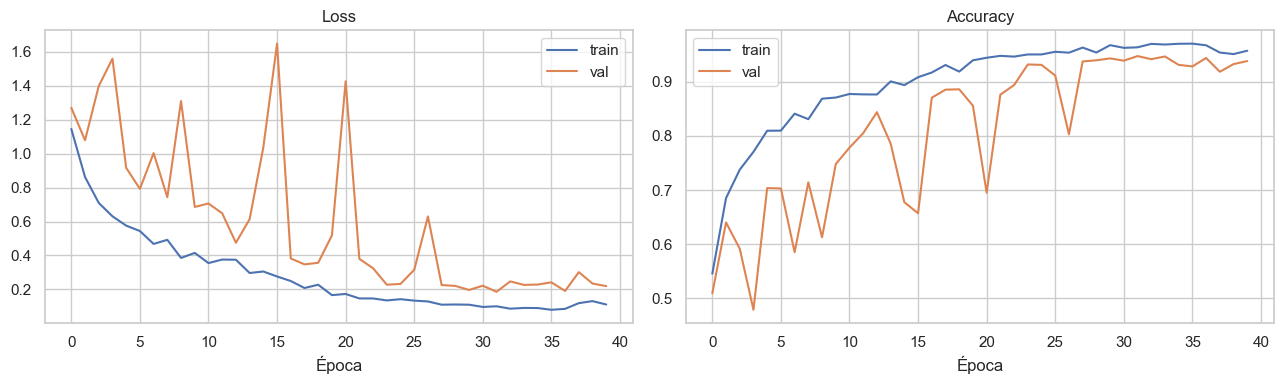

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(historia.history['loss'], label='train')
axes[0].plot(historia.history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Época'); axes[0].legend()

axes[1].plot(historia.history['accuracy'], label='train')
axes[1].plot(historia.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época'); axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Evaluación sobre el conjunto de TEST

El conjunto de test no se ha visto ni durante el entrenamiento ni durante el early stopping (que usa val). Es la métrica honesta del modelo.

Métricas: accuracy + **F1 macro** (insensible al desbalance) + matriz de confusión + classification report por clase.

In [7]:
y_pred_proba = modelo.predict(X_test, verbose=0)
y_pred = y_pred_proba.argmax(axis=1)

acc = accuracy_score(y_test, y_pred)
f1_m = f1_score(y_test, y_pred, average='macro')
print(f'Accuracy (test): {acc:.4f}')
print(f'F1 macro (test): {f1_m:.4f}')
print()
print(classification_report(
    y_test, y_pred,
    target_names=[QUEEN_STATUS_NOMBRES[i] for i in range(N_CLASES)],
    digits=3,
))

Accuracy (test): 0.9310
F1 macro (test): 0.9162

                       precision    recall  f1-score   support

       Reina original      0.963     0.842     0.898       215
            Sin reina      0.835     0.948     0.888       192
Reina nueva rechazada      0.905     0.938     0.921       306
 Reina nueva aceptada      0.964     0.950     0.957       707

             accuracy                          0.931      1420
            macro avg      0.917     0.920     0.916      1420
         weighted avg      0.934     0.931     0.931      1420



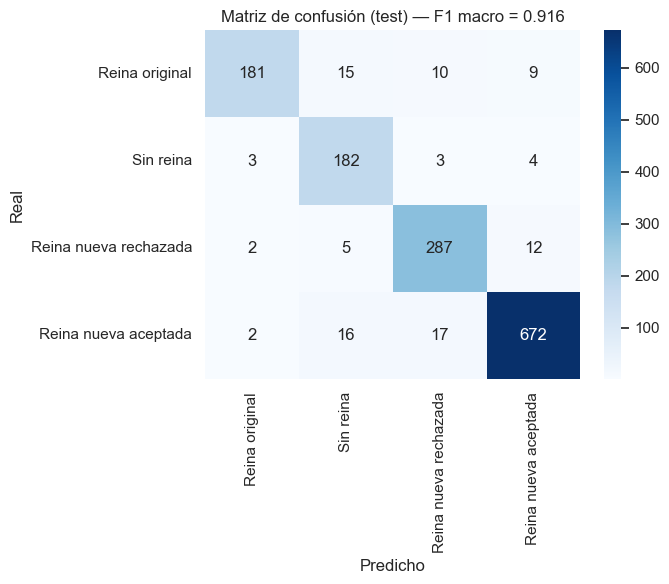

In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[QUEEN_STATUS_NOMBRES[i] for i in range(N_CLASES)],
    yticklabels=[QUEEN_STATUS_NOMBRES[i] for i in range(N_CLASES)],
    ax=ax,
)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de confusión (test) — F1 macro = {f1_m:.3f}')
plt.tight_layout()
plt.show()

---

## 6. Inferencia sobre audio de duración arbitraria

Caso de uso real: el apicultor sube un audio de **X minutos**. La función `predecir_audio` lo trocea en chunks de 60 s (idéntica longitud que los segmentos de entrenamiento), predice cada chunk y agrega los resultados.

Estrategias de agregación:

- **Promedio de probabilidades** (recomendado): suma las softmax de cada chunk y se queda con el argmax. Más robusto que voto duro porque tiene en cuenta la confianza de cada chunk.
- **Voto mayoritario**: cada chunk vota por su clase, gana la más votada. Lo devolvemos también para comparar.

Si el audio dura menos de 60 s se padea con silencio. Si dura más, se procesan **todos** los chunks completos y se descartan los segundos sobrantes (`< 60 s` finales) si no llegan a un umbral mínimo (3 s) — un chunk muy corto distorsiona la predicción.

In [ ]:
SR_INF = int(data['sr'])
N_MELS_INF = int(data['n_mels'])
HOP_INF = int(data['hop'])
T_FIXED_INF = int(data['t_fixed'])
DURACION_CHUNK = 60.0  # s

print(f'SR={SR_INF}  n_mels={N_MELS_INF}  hop={HOP_INF}  T_FIXED={T_FIXED_INF}')

SR=22050  n_mels=128  hop=512  T_FIXED=2584


In [ ]:
def _audio_chunk_a_mel(y_chunk: np.ndarray) -> np.ndarray:
    mel = librosa.feature.melspectrogram(
        y=y_chunk, sr=SR_INF, n_mels=N_MELS_INF, n_fft=2048, hop_length=HOP_INF
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    T = mel_db.shape[1]
    if T < T_FIXED_INF:
        mel_db = np.pad(mel_db, ((0, 0), (0, T_FIXED_INF - T)),
                        mode='constant', constant_values=mel_db.min())
    elif T > T_FIXED_INF:
        mel_db = mel_db[:, :T_FIXED_INF]

    mu, sigma = mel_db.mean(), mel_db.std() + 1e-6
    mel_db = (mel_db - mu) / sigma
    return mel_db.astype(np.float32)


def _trocear(y: np.ndarray, sr: int, dur_chunk_s: float = DURACION_CHUNK,
             min_resto_s: float = 3.0) -> list:

    n = int(dur_chunk_s * sr)
    chunks = []
    for inicio in range(0, len(y), n):
        c = y[inicio: inicio + n]
        if len(c) == n:
            chunks.append(c)
        elif len(c) >= int(min_resto_s * sr):
            c_pad = np.pad(c, (0, n - len(c)), mode='constant')
            chunks.append(c_pad)
    if not chunks:
        c_pad = np.pad(y, (0, max(0, n - len(y))), mode='constant')
        chunks.append(c_pad[:n])
    return chunks


def predecir_audio(ruta_audio: str, modelo_keras=None, mostrar=True) -> dict:

    if modelo_keras is None:
        modelo_keras = modelo 

    y_audio, sr = librosa.load(ruta_audio, sr=SR_INF, mono=True)
    duracion = len(y_audio) / sr

    chunks = _trocear(y_audio, sr)
    mels = np.stack([_audio_chunk_a_mel(c) for c in chunks])
    mels = np.transpose(mels, (0, 2, 1))

    probs = modelo_keras.predict(mels, verbose=0)
    preds_chunk = probs.argmax(axis=1)

    # Agregación: promedio de probabilidades
    probs_global = probs.mean(axis=0)
    pred_global = int(probs_global.argmax())
    conf_global = float(probs_global[pred_global])

    # Voto mayoritario (alternativo)
    voto = int(np.bincount(preds_chunk, minlength=N_CLASES).argmax())

    resultado = {
        'prediccion_global': pred_global,
        'nombre_global': QUEEN_STATUS_NOMBRES[pred_global],
        'confianza_global': conf_global,
        'voto_mayoritario': voto,
        'voto_mayoritario_nombre': QUEEN_STATUS_NOMBRES[voto],
        'probs_globales': probs_global,
        'predicciones_chunk': preds_chunk.tolist(),
        'probs_chunk': probs,
        'n_chunks': len(chunks),
        'duracion_audio_s': duracion,
    }

    if mostrar:
        print(f'Audio: {os.path.basename(ruta_audio)}')
        print(f'Duración: {duracion:.1f} s → {len(chunks)} chunks de 60 s')
        print()
        print('Predicción por chunk:')
        for i, (p, pr) in enumerate(zip(preds_chunk, probs)):
            print(f'  Chunk {i+1}: clase {p} ({QUEEN_STATUS_NOMBRES[p]})  '
                  f'— probs: {np.round(pr, 3)}')
        print()
        print(f'==> Predicción del audio completo: '
              f'{QUEEN_STATUS_NOMBRES[pred_global]} '
              f'(confianza {conf_global*100:.1f}%)')
        if voto != pred_global:
            print(f'    [Nota: voto mayoritario sería {QUEEN_STATUS_NOMBRES[voto]} — '
                  f'discrepa con el promedio de probabilidades]')
    return resultado

### Demo de inferencia

Cogemos un audio aleatorio del set de validación y lo pasamos por la función. Como cada `.wav` del dataset dura exactamente 60 s, devolverá un único chunk; la prueba útil de verdad es cuando el apicultor suba un audio de varios minutos.

In [ ]:
idx_demo = test_idx[0]
ruta_demo = RUTA_AUDIOS / str(segmentos[idx_demo])
print(f'Etiqueta real: {QUEEN_STATUS_NOMBRES[int(y[idx_demo])]}\n')

_ = predecir_audio(str(ruta_demo))

Etiqueta real: Reina original

Audio: 2022-06-05--17-41-01_2__segment0.wav
Duración: 60.0 s → 1 chunks de 60 s

Predicción por chunk:
  Chunk 1: clase 0 (Reina original)  — probs: [0.502 0.022 0.475 0.002]

==> Predicción del audio completo: Reina original (confianza 50.2%)
